In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import GaussianNB 
from  sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import SVC
import pandas as pd

from sklearn.datasets import fetch_california_housing
url = r"C:\Users\phadt\Downloads\housing.csv.zip"
df = pd.read_csv(url)
housing = fetch_california_housing(as_frame= True)
df = housing.frame 

print("housing.csv:")
print(df.head)

housing.csv:
<bound method NDFrame.head of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37 

In [3]:
X = df.drop(columns=["MedHouseVal"])
y= df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

#Linear regression using one feature for demo 
lin_reg_single = LinearRegression()
lin_reg_single.fit(X_train[["MedInc"]], y_train)

y_pred_single = lin_reg_single.predict(X_test[["MedInc"]])
print("\nLinear Regression (single Feature - MedInc):")
print("MSE:", mean_squared_error(y_test, y_pred_single))
print("R2 Score:", r2_score(y_test, y_pred_single))

# Multivariable regression 
lin_reg_multi = LinearRegression()
lin_reg_multi.fit(X_train, y_train)

y_pred_multi = lin_reg_multi.predict(X_test)
print("\nMultivariable Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("R2 Score:", r2_score(y_test,y_pred_multi))
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Decision Tree Regressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

print("\nDecision Tree Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_tree))
print("R2 Score:", r2_score(y_test, y_pred_tree))

# Random Forest Regressor
forest_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
forest_reg.fit(X_train, y_train)
y_pred_forest = forest_reg.predict(X_test)

print("\nRandom Forest Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_forest))
print("R2 Score:", r2_score(y_test, y_pred_forest))
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, gamma=0.1))
])

svr_pipeline.fit(X_train, y_train)
y_pred_svr = svr_pipeline.predict(X_test)

print("\nSupport Vector Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("R2 Score:", r2_score(y_test, y_pred_svr))

# Conver Regression = classification 
# Expidfensive (1) if MedHouseVal > median, else Affordable (0)

median_price = df["MedHouseVal"].median()
df["Expensive"] =  (df["MedHouseVal"] > median_price).astype(int)


X_cls = df.drop(columns = ["MedHouseVal", "Expensive"])
y_cls = df.drop(columns = ["MedHouseVal","Expensive"])

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)





Linear Regression (single Feature - MedInc):
MSE: 0.7091157771765548
R2 Score: 0.45885918903846656

Multivariable Regression:
MSE: 0.5558915986952442
R2 Score: 0.575787706032451

Decision Tree Regression:
MSE: 0.495235205629094
R2 Score: 0.622075845135081

Random Forest Regression:
MSE: 0.2539759249192041
R2 Score: 0.8061857564039718

Support Vector Regression:
MSE: 0.3245027143040497
R2 Score: 0.7523653151860543


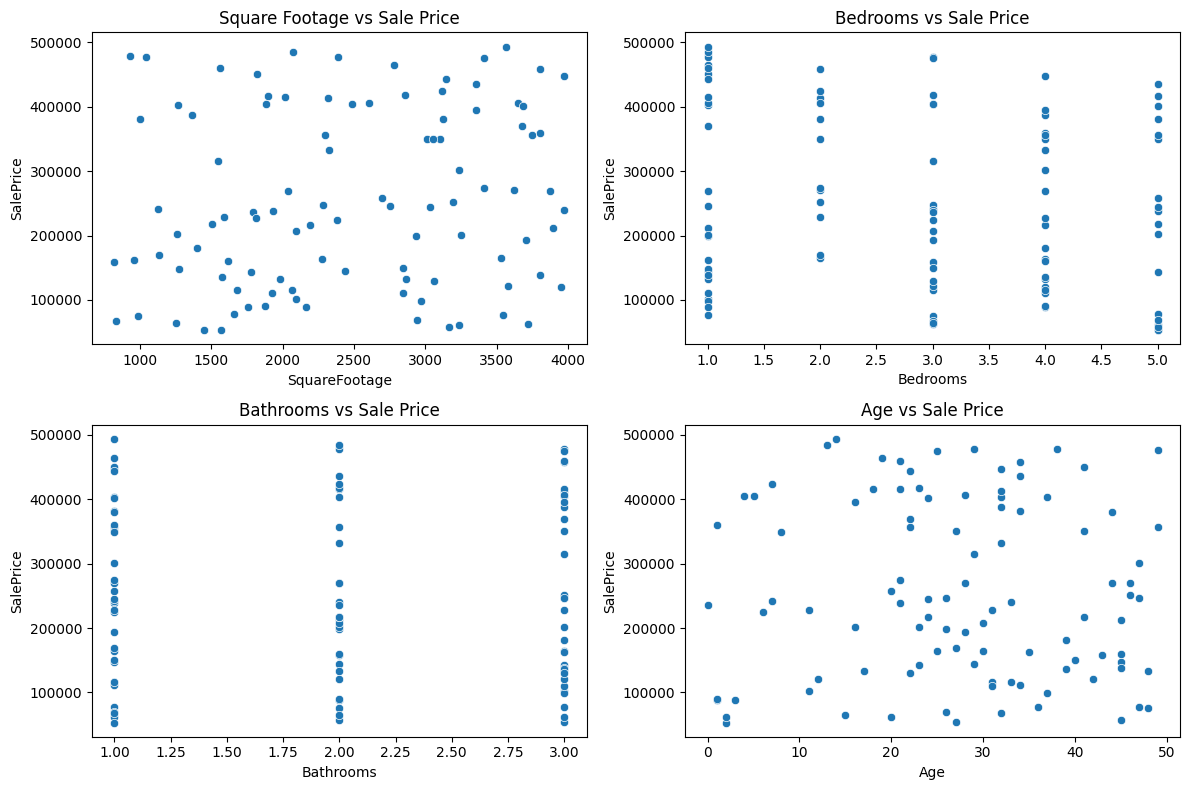

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Synthetic Dataset
# -----------------------------
np.random.seed(42)
data = pd.DataFrame({
    'SquareFootage': np.random.randint(800, 4000, 100),
    'Bedrooms': np.random.randint(1, 6, 100),
    'Bathrooms': np.random.randint(1, 4, 100),
    'Age': np.random.randint(0, 50, 100),
    'Location': np.random.choice(['Urban','Suburban','Rural'], 100),
    'SalePrice': np.random.randint(50000, 500000, 100)
})

# -----------------------------
# 2. Scatter Plots
# -----------------------------
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.scatterplot(x='SquareFootage', y='SalePrice', data=data)
plt.title('Square Footage vs Sale Price')

plt.subplot(2,2,2)
sns.scatterplot(x='Bedrooms', y='SalePrice', data=data)
plt.title('Bedrooms vs Sale Price')

plt.subplot(2,2,3)
sns.scatterplot(x='Bathrooms', y='SalePrice', data=data)
plt.title('Bathrooms vs Sale Price')

plt.subplot(2,2,4)
sns.scatterplot(x='Age', y='SalePrice', data=data)
plt.title('Age vs Sale Price')

plt.tight_layout()
plt.show()



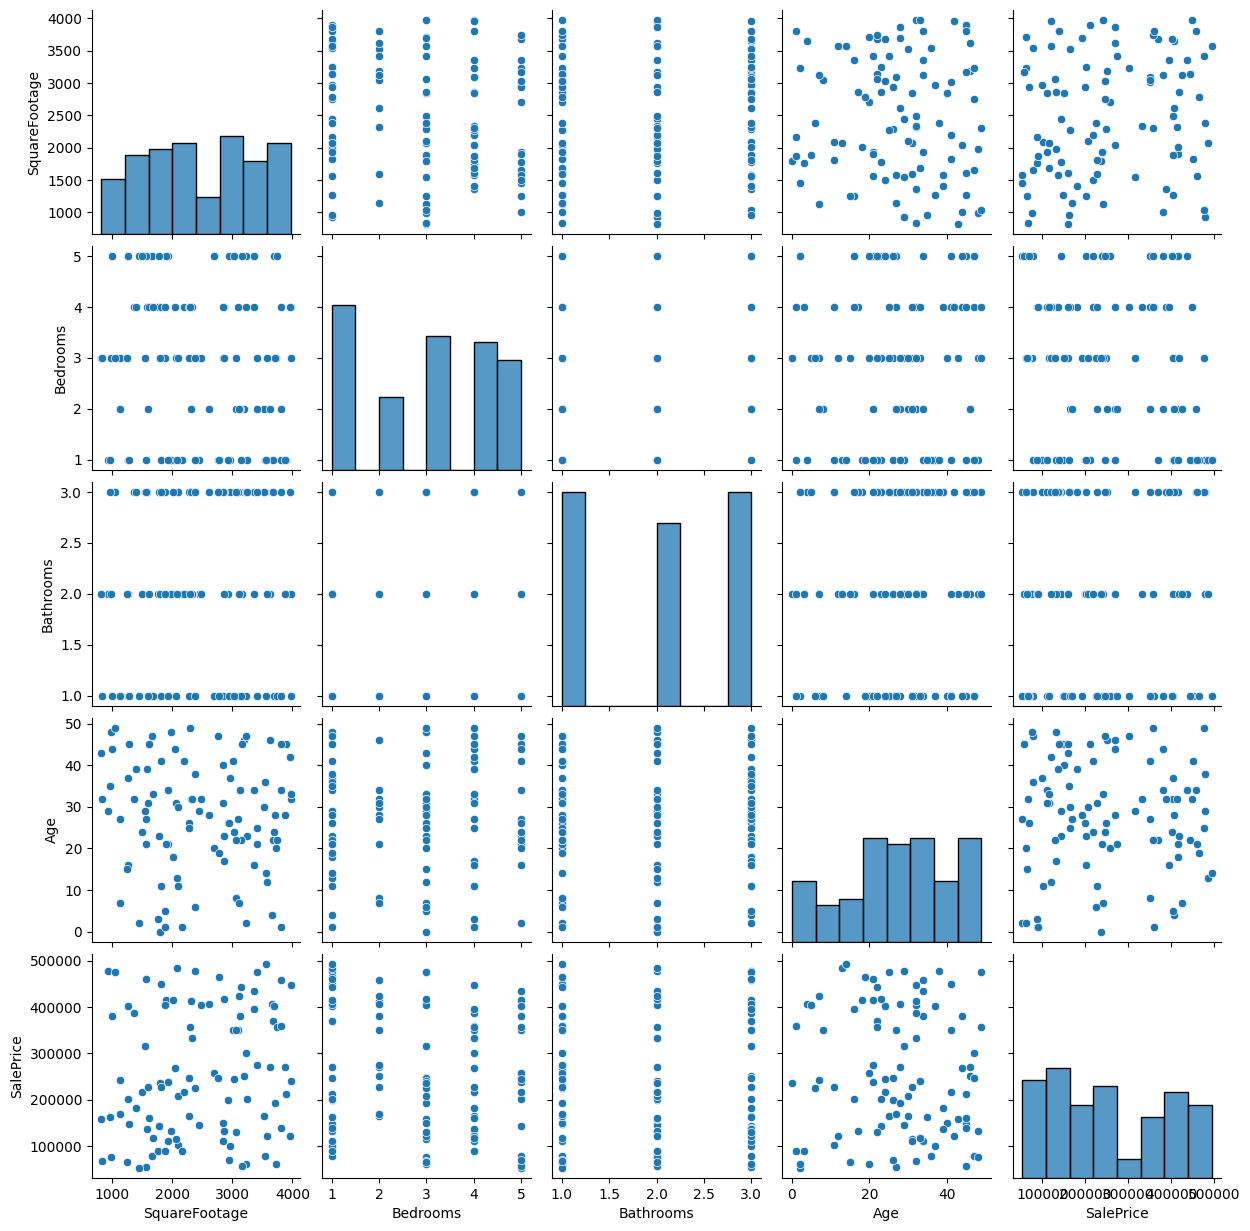

In [5]:
# 3. Pairplot
# -----------------------------
sns.pairplot(data[['SquareFootage','Bedrooms','Bathrooms','Age','SalePrice']])
plt.show()


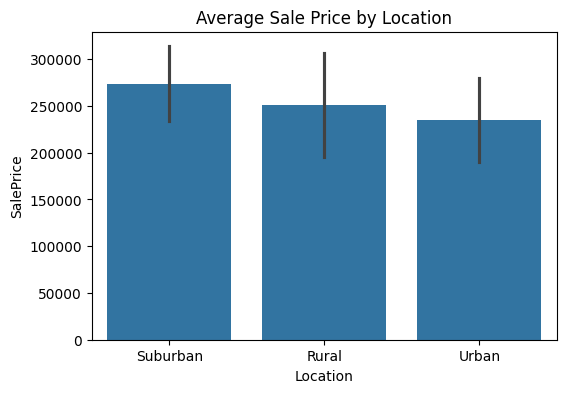

In [6]:
# 4. Bar Chart (Location)
# -----------------------------
plt.figure(figsize=(6,4))
sns.barplot(x='Location', y='SalePrice', data=data, estimator=np.mean)
plt.title('Average Sale Price by Location')
plt.show()

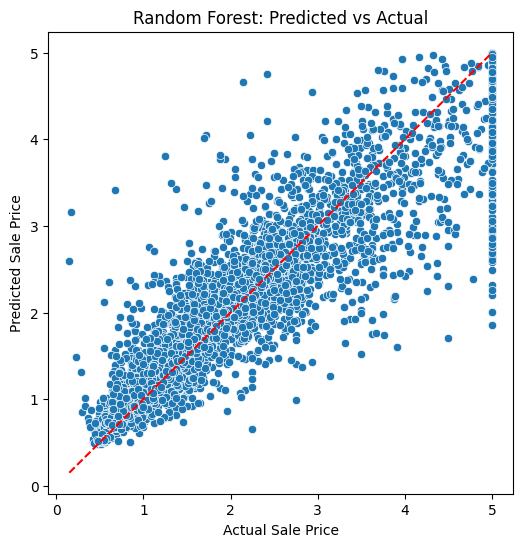

In [13]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(X_train, y_train)



results = {
    "Random Forest": {
        "Predictions": forest_reg.predict(X_test)
    }
}

forest_reg = forest_reg.predict(X_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=forest_reg)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Random Forest: Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

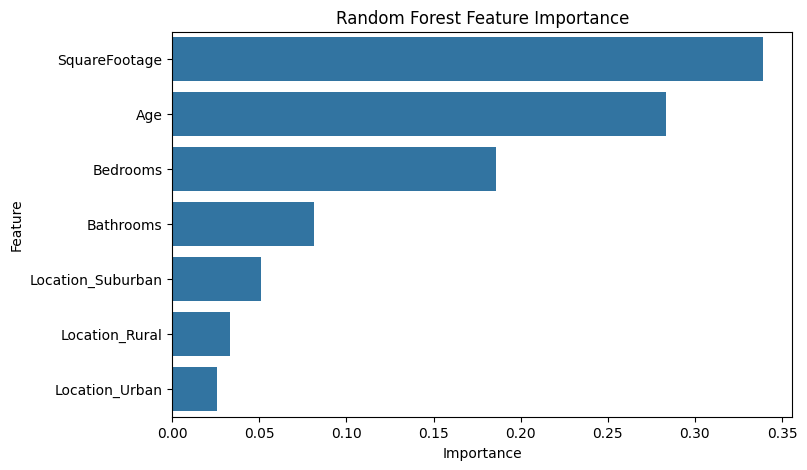

In [ ]:
# 7. Feature Importance (Random Forest)
# -----------------------------
rf_model = results["Random Forest"]["Model"].named_steps["regressor"]
feature_names = numeric + list(results["Random Forest"]["Model"].named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(categorical))
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Random Forest Feature Importance")
plt.show()


In [ ]:
# Print results 
for name, metrics in results.items():
    print(f"{name}: RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.2f}")

Linear Regression: RMSE=143353.88, R2=-0.49
Random Forest: RMSE=125987.01, R2=-0.15
Gradient Boosting: RMSE=139766.70, R2=-0.42


In [14]:
import pickle
from sklearn.ensemble import RandomForestRegressor

# Train model
forest_reg = RandomForestRegressor()
forest_reg.fit(X_train, y_train)

# Save to pickle file
with open("forest_reg.pkl", "wb") as f:
    pickle.dump(forest_reg, f)